In [2]:
# Cell 1: Load the dataset
import pandas as pd
df = pd.read_csv("dataset/water_potability.csv")

In [3]:
print(f"Number of records (Rows): {df.shape[0]}")

Number of records (Rows): 3276


In [4]:
print(f"Number of features (Columns): {df.shape[1]}")

Number of features (Columns): 10


In [5]:
print("Target variable: 'Potability' (1 = Potable, 0 = Not Potable)\n")

Target variable: 'Potability' (1 = Potable, 0 = Not Potable)



In [6]:
print("--- Data Types ---")
print(df.dtypes)

--- Data Types ---
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


In [7]:
print("\n---Missing Values ---")
print(df.isnull().sum())


---Missing Values ---
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64


In [8]:
print(f"\n---Duplicate Records ---")
print(f"Total duplicates: {df.duplicated().sum()}")


---Duplicate Records ---
Total duplicates: 0


In [9]:
print(df.describe())

                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085    41.416840   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.093092   176.850538  15666.690297     6.127421   307.699498   
50%       7.036752   196.967627  20927.833607     7.130299   333.073546   
75%       8.062066   216.667456  27332.762127     8.114887   359.950170   
max      14.000000   323.124000  61227.196008    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Potability  
count   3276.000000     3276.000000      3114.000000  3276.000000  3276.000000  
mean     426.205111       14.284970        66.396293     3.966786     0.390110  
std       80.824064        3.308162        16.175008     0.780382     0.487849  


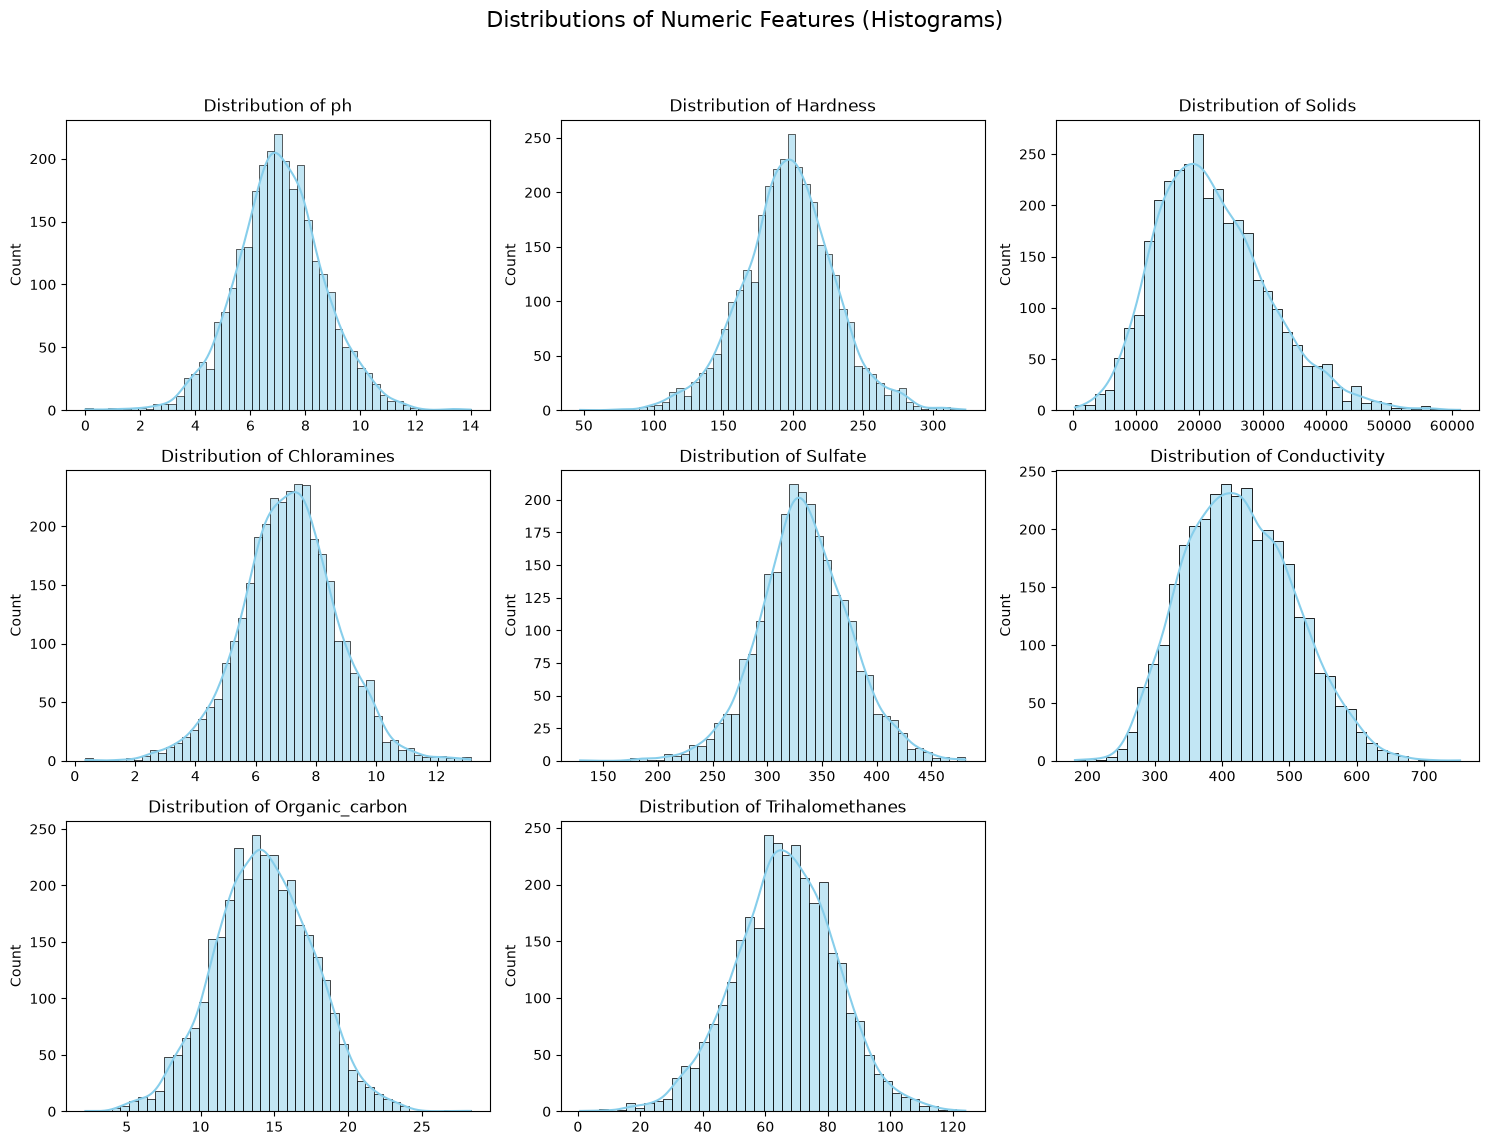

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = df.drop('Potability', axis=1).columns

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Distributions of Numeric Features (Histograms)', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel('')

fig.delaxes(axes[-1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

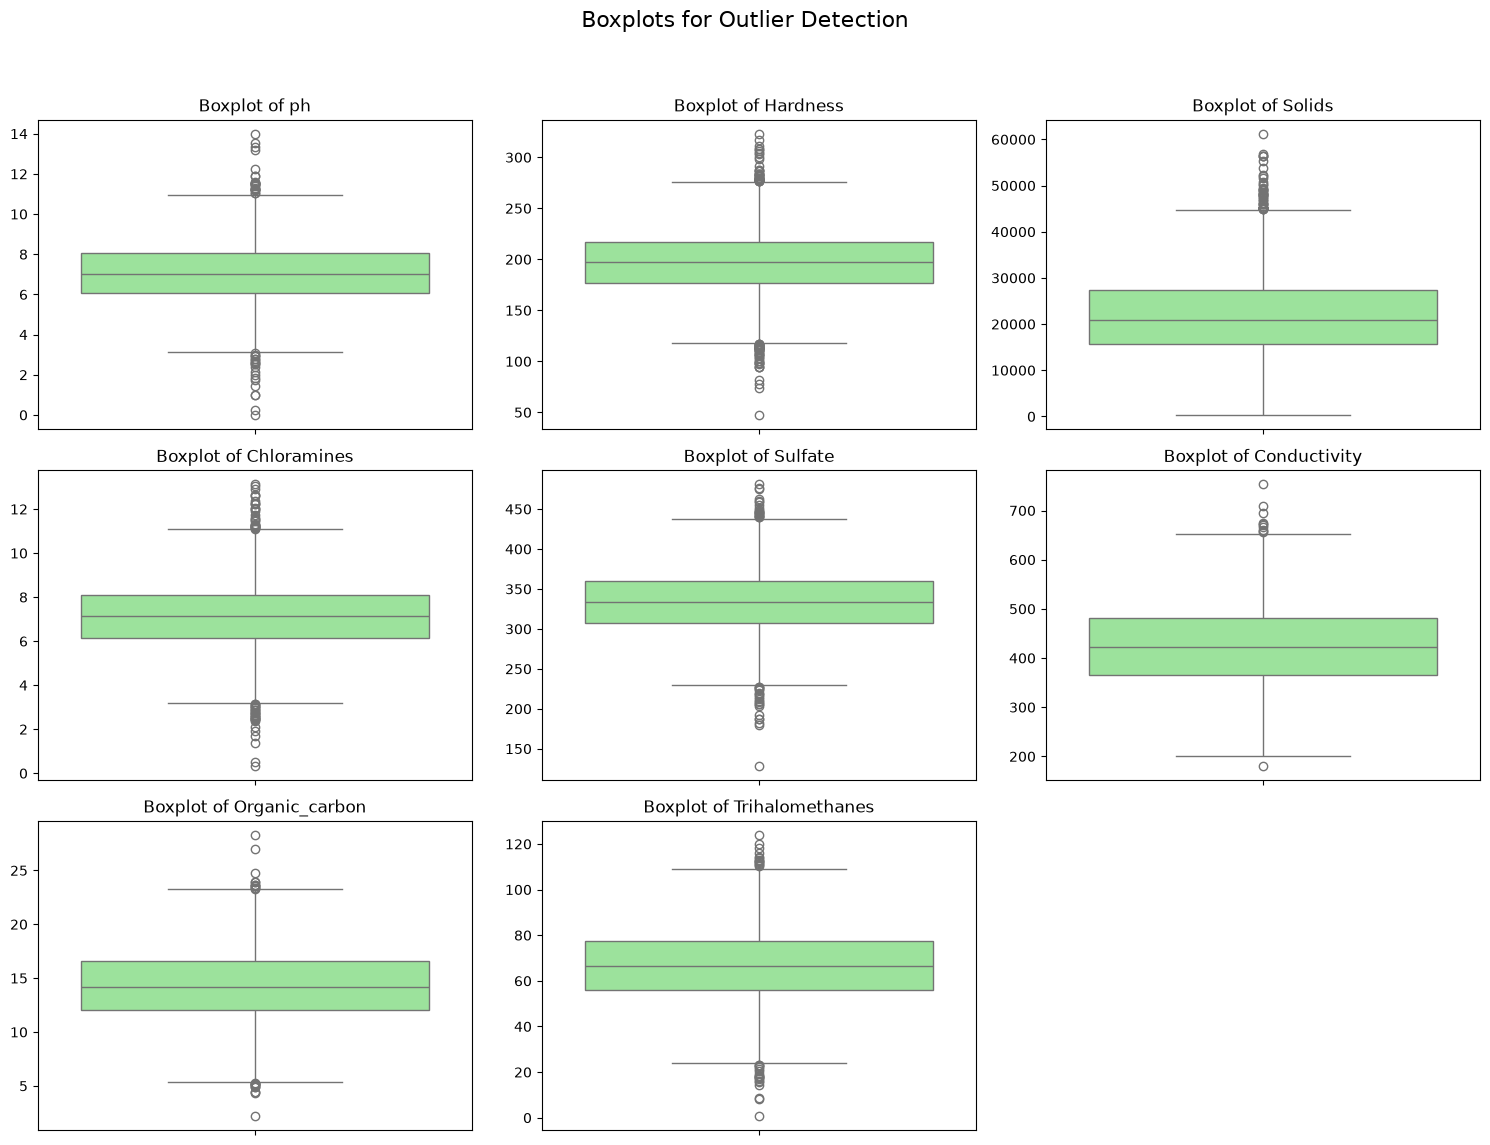

In [12]:
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 12))
fig.suptitle('Boxplots for Outlier Detection', fontsize=16)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightgreen')
    axes[i].set_title(f'Boxplot of {col}')
    axes[i].set_ylabel('')

fig.delaxes(axes[-1])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

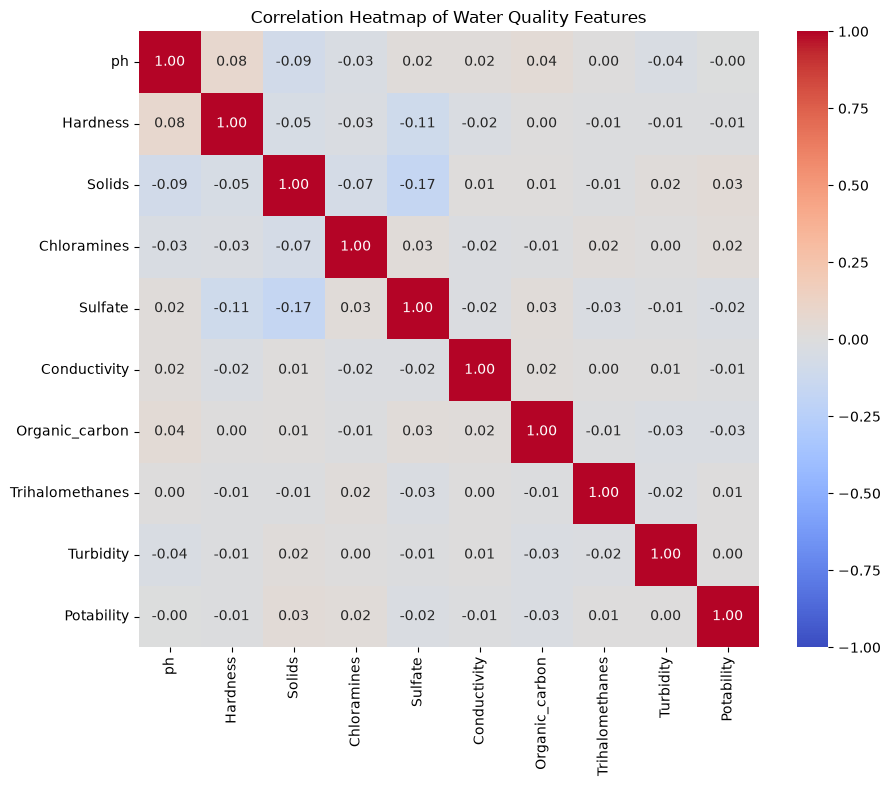

In [13]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Water Quality Features')
plt.show()

In [20]:
# Cell 2: Impute missing values with medians
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

print("Missing values in target columns filled successfully.")


Missing values in target columns filled successfully.


In [21]:
# Cell 3: Check and remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Total duplicate records found: {duplicate_count}")

if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New dataset shape: {df.shape}")
else:
    print("No duplicate records to remove.")


Total duplicate records found: 0
No duplicate records to remove.


In [22]:
# Cell 4: Verify remaining null values across all columns
missing_summary = df.isnull().sum()
print("Remaining Missing Values per Feature:")
print(missing_summary)

print(f"\nTotal remaining missing values: {missing_summary.sum()}")


Remaining Missing Values per Feature:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

Total remaining missing values: 0


In [24]:
# Cell 5: Check feature data types and concise info
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               3276 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          3276 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3276 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB
